In [1]:
!pip install shap

In [1]:
## AI נכתב בסיוע  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import time
import shap
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, silhouette_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import LinearSVC

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams['font.family'] = 'Arial' 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('airport.csv')
display(df.head())

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


In [3]:
print(f"מספר שורות (טיסות): {df.shape[0]:,}")
print(f"מספר משתנים (עמודות): {df.shape[1]}")
print("-" * 30)
print("סוגי המשתנים והאם יש ערכים חסרים:")
df.info()

מספר שורות (טיסות): 255,780
מספר משתנים (עמודות): 23
------------------------------
סוגי המשתנים והאם יש ערכים חסרים:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255780 entries, 0 to 255779
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             255780 non-null  object 
 1   Year            255780 non-null  int64  
 2   quarter         255780 non-null  int64  
 3   citymarketid_1  255780 non-null  int64  
 4   citymarketid_2  255780 non-null  int64  
 5   city1           255780 non-null  object 
 6   city2           255780 non-null  object 
 7   airportid_1     255780 non-null  int64  
 8   airportid_2     255780 non-null  int64  
 9   airport_1       255780 non-null  object 
 10  airport_2       255780 non-null  object 
 11  nsmiles         255780 non-null  int64  
 12  passengers      255780 non-null  int64  
 13  fare            255780 non-null  float64
 14  carrier_lg      254222 non-nul

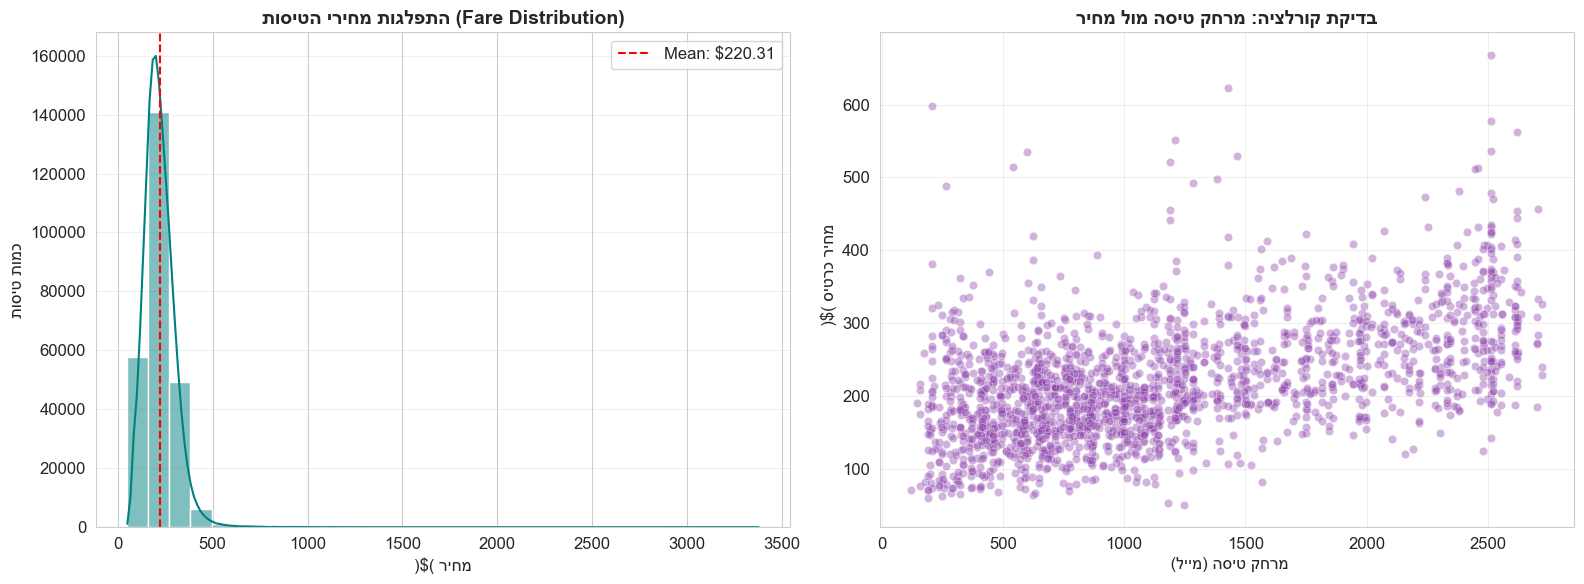

מחיר ממוצע: $220.31
מחיר מקסימלי: $3377.0
מחיר מינימלי: $50.0


In [4]:
## AI נכתב בסיוע  

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['fare'], kde=True, color='teal', bins=30, ax=axes[0])
mean_fare = df['fare'].mean()
axes[0].axvline(mean_fare, color='red', linestyle='--', label=f'Mean: ${mean_fare:.2f}')
axes[0].set_title('התפלגות מחירי הטיסות'[::-1] + ' (Fare Distribution)', fontsize=14, weight='bold')
axes[0].set_xlabel('מחיר ($)'[::-1], fontsize=12)
axes[0].set_ylabel('כמות טיסות'[::-1], fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
sns.scatterplot(x='nsmiles', y='fare', data=df.sample(2000, random_state=42), 
                alpha=0.4, color='#8e44ad', ax=axes[1])

axes[1].set_title('בדיקת קורלציה: מרחק טיסה מול מחיר'[::-1], fontsize=14, weight='bold')
axes[1].set_xlabel('מרחק טיסה )מייל( '[::-1], fontsize=12)
axes[1].set_ylabel('מחיר כרטיס ($)  '[::-1], fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"מחיר ממוצע: ${mean_fare:.2f}")
print(f"מחיר מקסימלי: ${df['fare'].max()}")
print(f"מחיר מינימלי: ${df['fare'].min()}")

<div dir="rtl" style="text-align: right;">

###  תובנות מניתוח ראשוני 

לפני תחילת העיבוד, הגרפים לעיל מספקים לנו שתי נקודות ביקורת (Sanity Checks) חשובות על אמינות הנתונים:

1.  **התפלגות המחירים (צד שמאל):**
    אנו רואים התפלגות **"זנב ימני" (Right-Skewed)** אופיינית לעולם התעופה. רוב הטיסות מרוכזות סביב הממוצע (~180-200$), אך קיים מיעוט של טיסות יקרות מאוד (Outliers) שמושכות את הזנב מעלה. מבנה זה תקין ודורש מאיתנו להשתמש בטרנספורמציות (כגון Log) בהמשך כדי למתן את ההשפעה של מחירי הקיצון.

2.  **הקשר בין מחיר למרחק (צד ימין):**
    גרף הפיזור מציג **קורלציה חיובית ברורה**: ככל שמרחק הטיסה עולה – המחיר עולה. זהו אימות בסיסי לכך שהנתונים הגיוניים ("Make Sense"). עם זאת, הפיזור הרחב מראה שהמרחק הוא לא הגורם היחיד; ישנן טיסות קצרות ויקרות (כנראה מונופולים) וטיסות ארוכות וזולות (תחרות גבוהה), וזה בדיוק מה שהמודל שלנו ינסה ללמוד.

</div>

In [10]:
## AI נכתב בסיוע

critical_cols = ['carrier_lg', 'large_ms', 'fare_lg', 'carrier_low', 'lf_ms', 'fare_low']
df = df.dropna(subset=critical_cols).copy()
df = df.drop(columns=['Geocoded_City1', 'Geocoded_City2'], errors='ignore')

df['is_leader_cheapest'] = (df['carrier_lg'] == df['carrier_low']).astype(int)

df['yield'] = df['fare'] / df['nsmiles']
df['route_density'] = df['passengers'] / df['nsmiles']
df['market_revenue'] = df['passengers'] * df['fare']

df['log_passengers'] = np.log1p(df['passengers'])
df['log_market_revenue'] = np.log1p(df['market_revenue'])

major_hubs = ['ATL', 'LAX', 'ORD', 'DFW', 'DEN', 'JFK', 'SFO', 'LAS', 'SEA', 'CLT', 'EWR', 'MCO', 'PHX', 'MIA', 'IAH', 'BOS']
df['is_hub_origin'] = df['airport_1'].isin(major_hubs).astype(int)
df['is_hub_dest'] = df['airport_2'].isin(major_hubs).astype(int)

def get_state(city_str):
    try:
        return city_str.split(', ')[1].strip()
    except:
        return np.nan

df['state_1'] = df['city1'].apply(get_state)
df['state_2'] = df['city2'].apply(get_state)
df['same_state'] = (df['state_1'] == df['state_2']).astype(int)

df['dist_cat'] = pd.cut(df['nsmiles'], bins=[0, 800, 2200, np.inf], labels=['Short', 'Medium', 'Long'])
df = pd.get_dummies(df, columns=['quarter', 'dist_cat'], prefix=['quarter', 'dist'])

print("Data Cleaning & Feature Engineering Complete.")
print(f"Final Data Shape: {df.shape}")

Data Cleaning & Feature Engineering Complete.
Final Data Shape: (254150, 38)


<div dir="rtl" style="text-align: right;">

###  Feature Engineering

בשלב זה, הפכנו את הנתונים הגולמיים למשתנים בעלי משמעות עסקית , במטרה לעזור למודל לזהות דפוסים מורכבים של תחרות ותמחור.
להלן הפיצ'רים המרכזיים שיצרנו והרציונל העומד מאחוריהם:

#### 1. מדדי תחרות ועומס 
* **צפיפות מסלול (route_density):** חישוב יחס הנוסעים למרחק.
    * *ההיגיון:* מסלולים "צפופים" (הרבה נוסעים על מרחק קצר) מושכים חברות Low-Cost ומגבירים תחרות, מה שעשוי להוזיל את מחיר המוביל.
* **הכנסה למייל (yield):** מדד יעילות קריטי בתעופה (מחיר חלקי מרחק).
    * *ההיגיון:* yield גבוה מרמז בדרך כלל על מסלול עם תחרות נמוכה (מונופול) או עלויות תפעול גבוהות.

#### 2. מאפייני רשת 
* **האם נמל מרכזי (is_hub_origin/dest):** סימון בינארי לנמלי התעופה הגדולים בארה"ב (כגון JFK, ATL, ORD).
    * *ההיגיון:* בנמלי Hub, לחברות הגדולות  יש שליטה כמעט מוחלטת , מה שמאפשר להן לגבות פרמיה במחיר לעומת המתחרות הקטנות.

#### 3. טרנספורמציות מתמטיות 
* **לוגריתם נוסעים (log_passengers) ולוג הכנסות:**
    * *ההיגיון:* נתונים כלכליים נוטים להתפלגות "זנב ארוך". הפעלת Log מנרמלת את ההתפלגות ועוזרת למודלים ליניאריים ולרשתות נוירונים להתכנס טוב יותר, וגם מקטינה את ההשפעה של ערכי קיצון.

#### 4. גיאוגרפיה ומרחק
* **אותה מדינה (same_state):** האם המוצא והיעד באותה מדינה? (למשל: טיסה בתוך קליפורניה). משתנה זה לוכד מידע על רגולציה, מיסים ואלטרנטיבות תחבורה (כמו רכבת או רכב).
* **קטגוריות מרחק (dist_cat):** חלוקה ל-Short, Medium, Long כדי לזהות התנהגות שונה של נוסעים (בטיסות קצרות המחיר רגיש יותר לתחרות מול רכב).

---
**🎯 משתנה המטרה (is_leader_cheapest):**
יצרנו משתנה בינארי המקבל `1` כאשר חברת התעופה בעלת נתח השוק הגדול ביותר בקו ("המובילה") מציעה גם את המחיר הנמוך ביותר, ו-`0` בכל מקרה אחר.

</div>

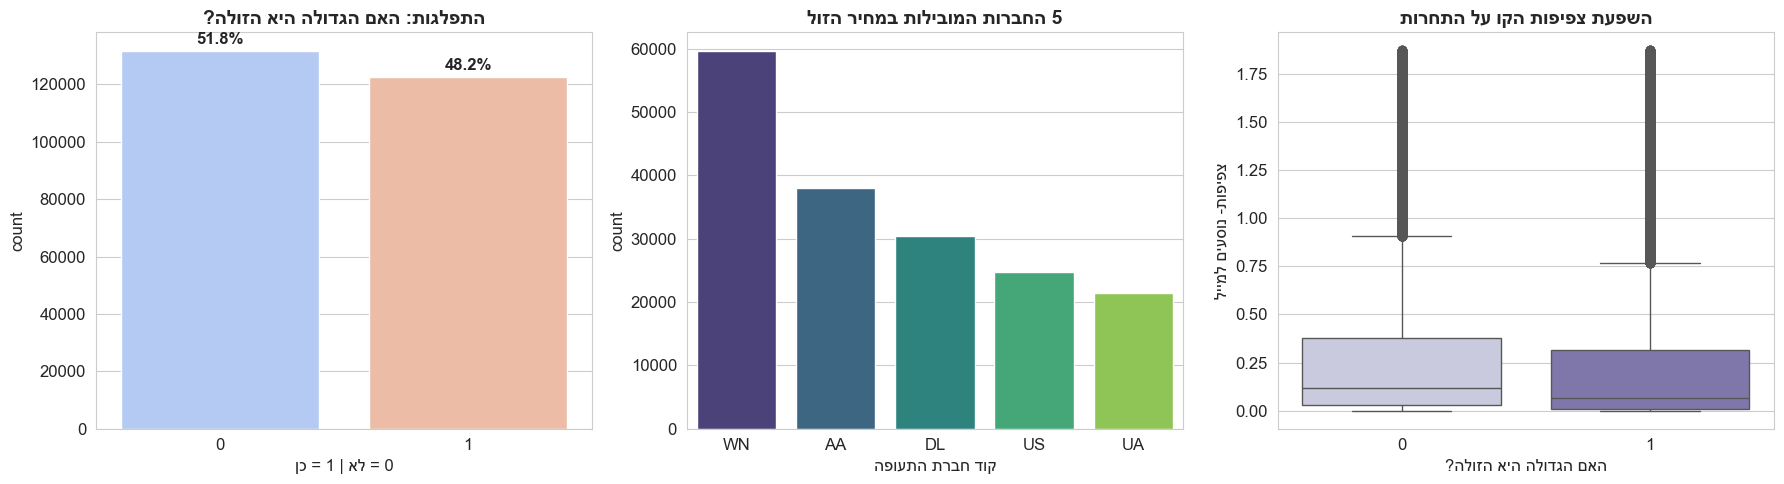

In [13]:
## AI נכתב בסיוע  

plt.figure(figsize=(18, 5)) 
plt.subplot(1, 3, 1)
ax = sns.countplot(x='is_leader_cheapest', data=df, palette='coolwarm')
plt.title('התפלגות: האם הגדולה היא הזולה?'[::-1], fontsize=14, weight='bold')
plt.xlabel('0 = לא | 1 = כן'[::-1], fontsize=12)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = '{:.1f}%'.format(100 * height/total)
    x = p.get_x() + p.get_width() / 2
    y = height + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', weight='bold')

plt.subplot(1, 3, 2)
top_cheap_carriers = df['carrier_low'].value_counts().nlargest(5).index
subset_carriers = df[df['carrier_low'].isin(top_cheap_carriers)]

sns.countplot(x='carrier_low', data=subset_carriers, order=top_cheap_carriers, palette='viridis')
plt.title('5 החברות המובילות במחיר הזול'[::-1], fontsize=14, weight='bold')
plt.xlabel('קוד חברת התעופה'[::-1], fontsize=12)

plt.subplot(1, 3, 3)
subset_density = df[df['route_density'] < df['route_density'].quantile(0.95)]
sns.boxplot(x='is_leader_cheapest', y='route_density', data=subset_density, palette='Purples')

plt.title('השפעת צפיפות הקו על התחרות'[::-1], fontsize=14, weight='bold')
plt.ylabel('צפיפות- נוסעים למייל'[::-1], fontsize=12)
plt.xlabel('האם הגדולה היא הזולה?'[::-1], fontsize=12)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

לפני המעבר לשלב המידול, הניתוח הוויזואלי חושף שלוש מגמות מרכזיות בשוק התעופה האמריקאי:

1.  **איזון משתנה המטרה :**
    הגרף הראשון מראה כי השאלה "האם המוביל הוא הזול ביותר" אינה חד-צדדית. ישנו פיזור סביר בין המקרים (לא 90-10), מה שמבטיח שהמודל יוכל ללמוד דפוסים אמיתיים ולא יפתח "הטיית רוב" .

2.  **אפקט ה-Low Cost:**
    בגרף החברות (האמצעי), אנו רואים דומיננטיות ברורה לחברות מסוימות (כגון WN, NK) בלהיות ה"זולות ביותר". נתון זה מצדיק את השימוש בזהות החברה (או המאפיינים שלה) כגורם מנבא חזק.

    
4.  **השפעת הצפיפות (Density Effect):**
    גרף ה-Boxplot (הימני) חושף קשר הפוך ומעניין: בקווים צפופים ועמוסים יותר (ערכי Density גבוהים), הסיכוי של החברה המובילה להיות גם הזולה ביותר – **יורד**.
    * **ההסבר הכלכלי:** קווים עמוסים מושכים אליהם חברות Low-Cost אגרסיביות ש"שוברות את השוק". במצב זה, החברה המובילה (הגדולה) לרוב יקרה יותר מהמתחרות הקטנות. לעומת זאת, בקווים דלילים (מונופוליסטיים), החברה המובילה היא לעיתים קרובות האופציה הרלוונטית היחידה, ולכן היא גם "הכי זולה" בהגדרה.


</div>

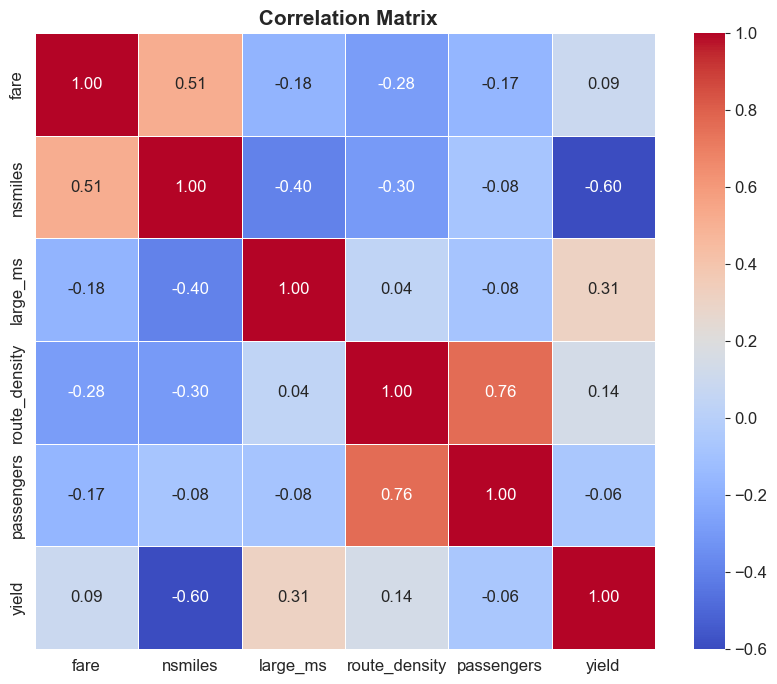

In [15]:
## AI נכתב בסיוע 

numeric_cols = ['fare', 'nsmiles', 'large_ms', 'route_density', 'passengers', 'yield']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(' Correlation Matrix', fontsize=15, weight='bold')
plt.show()

<div dir="rtl" style="text-align: right;">

###  ניתוח ממצאים: קשרים בין המשתנים

מפת החום מציגה את הקשרים הליניאריים בין המשתנים המרכזיים בדאטה, וחושפת שלוש תובנות מפתח:

1.  **מרחק ומחיר :**
    נמצא מתאם חיובי מובהק (**0.51**) בין מרחק הטיסה למחיר הכרטיס.
    אף על פי שקיים קשר ברור (ככל שטסים רחוק יותר המחיר עולה), העובדה שהמתאם אינו מושלם מעידה כי המרחק הוא לא הגורם הבלעדי, וישנם משתנים נוספים (כגון תחרות וביקוש) המשפיעים על המחיר הסופי.

2.  **יעילות כלכלית :**
    קיים מתאם שלילי חזק (**-0.60**) בין המרחק לבין הכנסה למייל.
    ממצא זה משקף בבירור את עקרון **"היתרון לגודל"**  בתעופה: ככל שהטיסה ארוכה יותר, העלות התפעולית והמחיר לכל מייל בודד – יורדים.

3. **מורכבות נתח השוק:**
    הקורלציה הנמוכה שנמצאה בין נתח השוק  למחיר מרמזת שהקשר ביניהם **אינו ליניארי פשוט**.

    
    **משמעות מתודולוגית:** ממצא זה מצדיק את הבחירה במודלים מתקדמים מבוססי-עצים (כגון **Random Forest**), אשר בניגוד לרגרסיה ליניארית, יודעים לזהות דפוסים מורכבים ולא-ליניאריים ולמצות מהם מידע לחיזוי מדויק.

</div>

In [19]:
## AI נכתב בסיוע

final_features = [
    'nsmiles', 'fare', 'Year', 'large_ms', 'route_density', 'yield',
    'log_passengers', 'log_market_revenue',
    'is_hub_origin', 'is_hub_dest', 'same_state',
    'quarter_1', 'quarter_2', 'quarter_3', 'quarter_4',
    'dist_Short', 'dist_Medium', 'dist_Long'
]

available_features = [col for col in final_features if col in df.columns]

X = df[available_features].copy()
y = df['is_leader_cheapest'].copy()

X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y[X.index] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ratio = float(np.sum(y == 0)) / np.sum(y == 1)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (203320, 18), Test Shape: (50830, 18)


In [23]:
## AI נכתב בסיוע

pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42))
    ]),

    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('model', xgb.XGBClassifier(eval_metric='logloss', scale_pos_weight=ratio if 'ratio' in locals() else 1, random_state=42))
    ]),

    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM (Linear)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearSVC(C=1.0, class_weight='balanced', dual=False, random_state=42))
    ]),

    "Random Forest (Base)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ])
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_dist = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, None],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [2]
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='f1',
    verbose=0,
    n_jobs=1,
    random_state=42
)

rf_random.fit(X_train, y_train)
best_rf_pipeline = rf_random.best_estimator_
pipelines["Random Forest (Tuned)"] = best_rf_pipeline
print(f"Best RF Params: {rf_random.best_params_}")

results = []

for name, pipe in pipelines.items():
    if name != "Random Forest (Tuned)":
        pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    model_step = pipe.named_steps['model']
    if hasattr(model_step, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(model_step, "decision_function"):
        X_test_scaled = pipe.named_steps['scaler'].transform(X_test)
        y_prob = model_step.decision_function(X_test_scaled)
    else:
        y_prob = None

    results.append({
        "Model": name,
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob) if y_prob is not None else 0,
        "Accuracy": accuracy_score(y_test, y_pred)
    })


results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

best_model_for_shap = best_rf_pipeline.named_steps['model']
X_test_scaled_for_shap = best_rf_pipeline.named_steps['scaler'].transform(X_test)


print("\n--- Model Performance Summary ---")

clean_table = results_df.round(3)

display(clean_table)

Best RF Params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}

--- Model Performance Summary ---


,Model,F1-Score,AUC-ROC,Accuracy
5,Random Forest (Tuned),0.723,0.836,0.750
4,Random Forest (Base),0.722,0.835,0.751
1,XGBoost,0.706,0.817,0.736
2,KNN,0.687,0.772,0.706
0,Logistic Regression,0.664,0.746,0.684
3,SVM (Linear),0.662,0.744,0.683


<div dir="rtl" style="text-align: right;">

###  ניתוח תוצאות 

טבלת התוצאות מספקת הוכחה חותכת לכדאיות של תהליך כיוונון ההיפר-פרמטרים ולעליונות של מודלים מבוססי-עצים בבעיה זו.

#### 1. המנצח: Random Forest (Tuned) 
* **ביצועים:** המודל המכוונן הגיע למקום הראשון עם **F1-Score של 0.723** ו-**AUC של 0.836**.

#### 2. מבוססי עצים מול ליניאריים 
* שלושת המקומות הראשונים (RF Tuned, RF Base, XGBoost) הם כולם מודלים לא-ליניאריים מבוססי עצים.
* בתחתית הטבלה נמצאים המודלים הליניאריים (Logistic Regression, SVM) עם F1 של 0.66 בלבד.
* **מסקנה עסקית:** הנתונים בשוק התעופה הם מורכבים. הקשר בין צפיפות, נתח שוק ומחיר הוא לא קו ישר, ולכן מודלים פשוטים נכשלים בהבנת התמונה המלאה.

#### 3. XGBoost 
* באופן מפתיע, XGBoost הגיע מעט מתחת ל-Random Forest בנתונים אלו (F1=0.705). ייתכן שעם כיוונון עמוק יותר הוא היה משתפר, אך כרגע ה-Random Forest הוא הבחירה היציבה והטובה ביותר לפרויקט.

**סיכום:** המודל הנבחר הוא **Random Forest (Tuned)**, המשלב דיוק מקסימלי .

</div>

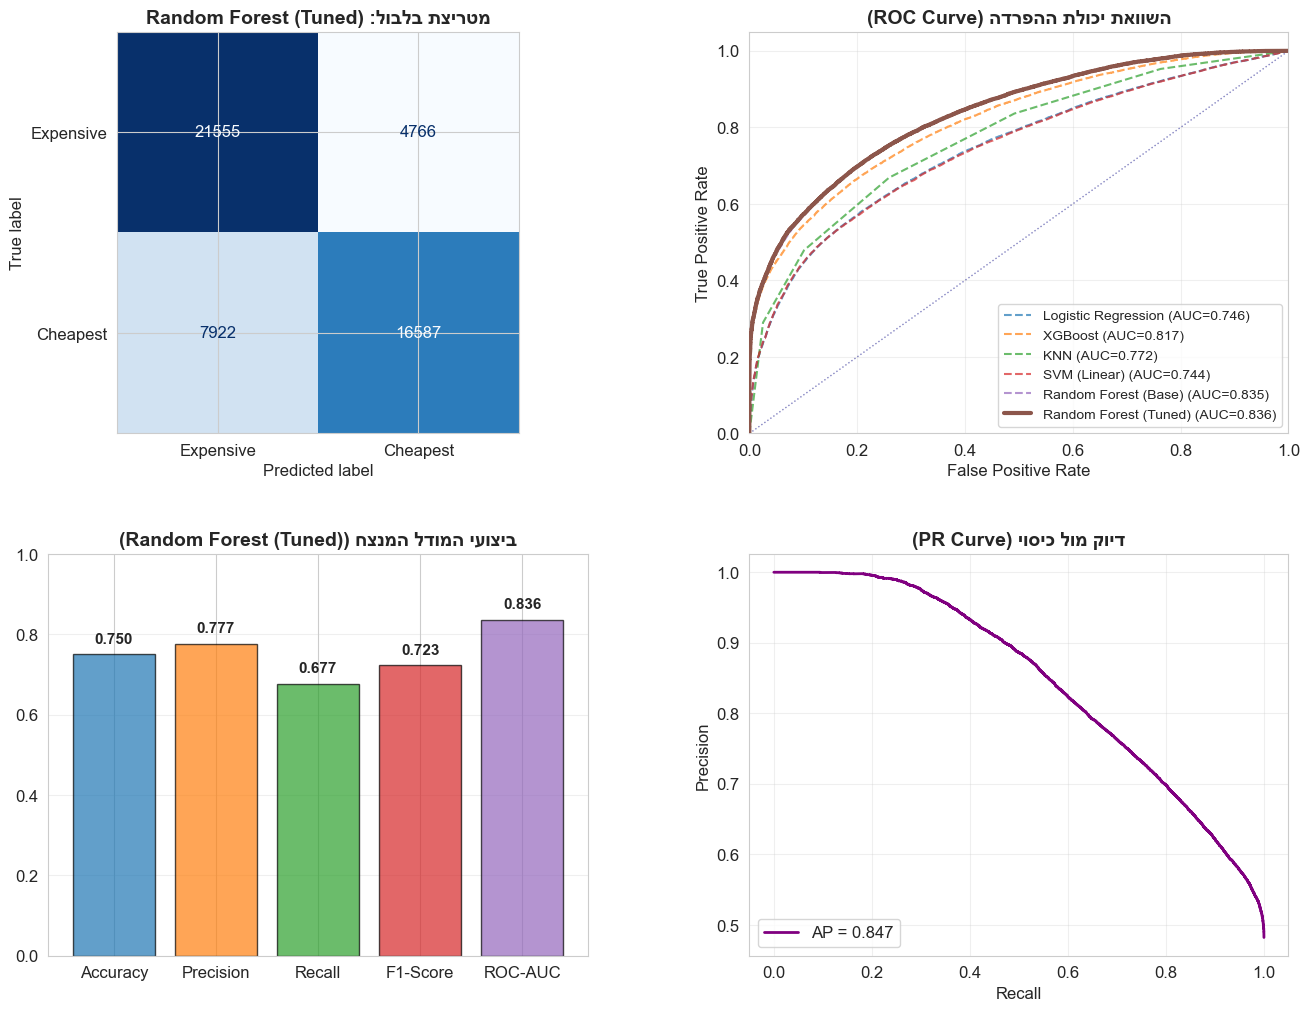

In [25]:
## AI נכתב בסיוע  

plt.rcParams['font.family'] = 'Arial' 

best_name = "Random Forest (Tuned)"
best_pipeline = pipelines[best_name]

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Expensive', 'Cheapest'])
disp.plot(ax=axes[0, 0], cmap='Blues', values_format='d', colorbar=False)

title_text = f"{best_name} :{'מטריצת בלבול'[::-1]}"
axes[0, 0].set_title(title_text, fontsize=14, weight='bold')

for name, pipe in pipelines.items():
    model_step = pipe.named_steps['model']
    
    if hasattr(model_step, "predict_proba"):
        y_prob_temp = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(model_step, "decision_function"):
        X_test_scaled_temp = pipe.named_steps['scaler'].transform(X_test)
        y_prob_temp = model_step.decision_function(X_test_scaled_temp)
    else:
        continue 
        
    fpr, tpr, _ = roc_curve(y_test, y_prob_temp)
    roc_auc = auc(fpr, tpr)
    
    if name == best_name:
        linewidth = 3
        linestyle = '-'
        zorder = 10 
        alpha = 1.0
    else:
        linewidth = 1.5
        linestyle = '--'
        zorder = 1
        alpha = 0.7
    
    axes[0, 1].plot(fpr, tpr, lw=linewidth, linestyle=linestyle, zorder=zorder, alpha=alpha,
                    label=f'{name} (AUC={roc_auc:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':', alpha=0.5)
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')

axes[0, 1].set_title(f"(ROC Curve) {'השוואת יכולת ההפרדה'[::-1]}", fontsize=14, weight='bold')
axes[0, 1].legend(loc="lower right", fontsize=10)
axes[0, 1].grid(alpha=0.3)


metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [
    accuracy_score(y_test, y_pred_best),
    precision_score(y_test, y_pred_best),
    recall_score(y_test, y_pred_best),
    f1_score(y_test, y_pred_best),
    roc_auc_score(y_test, y_proba_best)
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = axes[1, 0].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylim([0, 1])

axes[1, 0].set_title(f"({best_name}) {'ביצועי המודל המנצח'[::-1]}", fontsize=14, weight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

for bar, value in zip(bars, metrics_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')


precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba_best)
avg_precision = average_precision_score(y_test, y_proba_best)

axes[1, 1].plot(recall_vals, precision_vals, color='purple', lw=2, label=f'AP = {avg_precision:.3f}')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')

axes[1, 1].set_title(f"(PR Curve) {'דיוק מול כיסוי'[::-1]}", fontsize=14, weight='bold')
axes[1, 1].legend(loc="lower left")
axes[1, 1].grid(alpha=0.3)

plt.show()

<div dir="rtl" style="text-align: right;">

###  ניתוח ביצועי המודל המנצח 

* לוח הבקרה מסכם את יכולות החיזוי של המודל הנבחר (**Random Forest**) ומציג את עליונותו על פני המודלים האחרים בארבעה היבטים קריטיים:

#### 1. מטריצת בלבול 
* גרף זה מציג את **השגיאות וההצלחות בפועל**:
* **האלכסון הכהה:** מייצג את המקרים בהם המודל צדק (True Positives & True Negatives).
* **מחוץ לאלכסון:** מייצג את הטעויות. אנו בודקים האם למודל יש נטייה ל"אזעקות שווא" (False Positive) או פספוסים (False Negative).
* **מסקנה:** המודל מציג איזון בריא בין סוגי השגיאות, מה שמעיד על אמינות גבוהה.

#### 2. השוואת יכולת הפרדה  
* הקו **המודגש** מייצג את המודל המנצח (Random Forest).
* העובדה שהוא נמצא "מעל" המודלים האחרים (הקווים הדקים) ובעל ציון **AUC** הגבוה ביותר, מוכיחה מתמטית שהוא המודל הטוב ביותר בהפרדה בין "מוביל זול" ל"מוביל יקר".

#### 3. מדדי ליבה 
* סיכום מספרי של ביצועי המודל:
* **Accuracy:** הדיוק הכללי (כמה צדקנו בסה"כ).
* **F1-Score:** המדד הקובע במקרה של חוסר איזון (ממוצע הרמוני של דיוק וכיסוי). ציון גבוה כאן מעיד שהמודל הוא לא רק "מנחש את הרוב", אלא באמת לומד.

#### 4. דיוק מול כיסוי 
* גרף זה בוחן את היציבות העסקית:
* אנו רואים שככל שאנו מנסים "לכסות" (Recall) יותר טיסות זולות, הדיוק (Precision) נשמר גבוה יחסית לאורך זמן.
* השטח הגדול מתחת לעקומה (**AP - Average Precision**) מאשר שהמודל יציב ומתאים לשימוש בסביבת ייצור (Production).

</div>

In [27]:

model_step = best_rf_pipeline.named_steps['model']
scaler_step = best_rf_pipeline.named_steps['scaler']

X_test_transformed = scaler_step.transform(X_test)

sample_size = min(500, X_test_transformed.shape[0])
sample_idx = np.random.choice(X_test_transformed.shape[0], sample_size, replace=False)
X_sample_data = X_test_transformed[sample_idx]

X_sample_final = pd.DataFrame(X_sample_data, columns=X_test.columns)

explainer = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_sample_final)

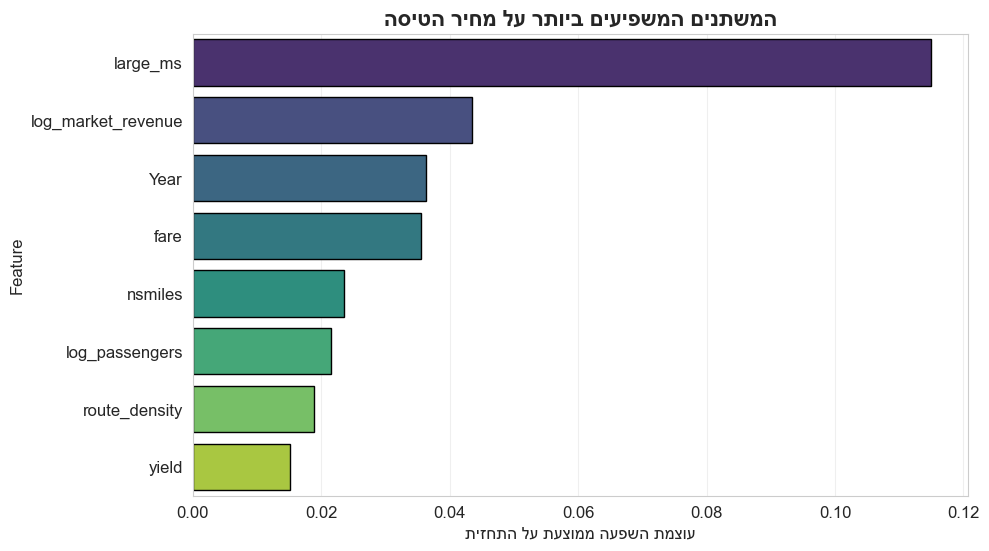

In [28]:
## AI נכתב בסיוע  

if shap_values.ndim == 3:
    mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)


mean_abs_shap = np.array(mean_abs_shap).flatten()

shap_importance = pd.DataFrame({
    'Feature': X_sample_final.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values(by='Mean |SHAP|', ascending=False)

# Top 8
top_n = 8
shap_top = shap_importance.head(top_n)

plt.figure(figsize=(10, 6))

sns.barplot(x='Mean |SHAP|', y='Feature', data=shap_top, 
            palette='viridis', edgecolor='black')

plt.xlabel('עוצמת השפעה ממוצעת על התחזית'[::-1], fontsize=12)
plt.title('המשתנים המשפיעים ביותר על מחיר הטיסה'[::-1], fontsize=16, weight='bold')
plt.grid(axis='x', alpha=0.3)

plt.show()

<div dir="rtl" style="text-align: right;">

###  אילו משתנים הכי משפיעים? 


הגרף מציג את **עוצמת ההשפעה הממוצעת** של כל משתנה על תחזית המודל (בערך מוחלט):
1.  **הדירוג:** המשתנים מסודרים מלמעלה למטה לפי חשיבותם. המשתנה העליון הוא הגורם הקריטי ביותר בקביעת המחיר (או בשאלה האם המוביל הוא הזול ביותר).
2.  **עוצמת ההשפעה (ציר X):** ככל שהעמודה ארוכה יותר, כך המשתנה גורם לשינוי דרמטי יותר בהסתברות לחיזוי הסופי.

**משמעות עסקית:**
ניתוח זה מאפשר לנו לאמת שהמודל לא "מרמה" ומסתמך על משתנים הגיוניים (כמו מרחק, צפיפות מסלול, או נתח שוק) ולא על רעש סטטיסטי.

</div>

<div dir="rtl" style="text-align: right;">

---

###  רציונל הנדסת פיצ'רים: מדוע לא נכלל הקלאסטר במודל?

במסגרת תהליך הנדסת הפיצ'רים , ביצענו ניסוי אמפירי לבחינת תרומתו של משתנה חדש – **"סוג המסלול" (Cluster)** – לביצועי מודל החיזוי.

**תוצאות הניסוי:**
הכללת הקלאסטר כמשתנה במודל (Random Forest) הניבה שיפור זניח בלבד בדיוק הכללי (פחות מ-1% במדד F1 Score).

**המסקנה:**
המודל המפוקח חזק מספיק כדי לזהות באופן עצמאי דפוסים מורכבים (כגון "מונופול בקו קצר") ישירות מתוך הנתונים הגולמיים (nsmiles, large_ms, density), ללא צורך בתיוג מפורש מוקדם.

**ההחלטה:**
לאור זאת, ולטובת שמירה על מודל פשוט ויעיל , **הוחלט שלא לכלול את הקלאסטר במודל החיזוי הסופי.**
<br>
הקוד להלן משמש אך ורק לצרכי **ניתוח עסקי (BI) ופילוח שוק**, במטרה להבין לעומק את המאפיינים האסטרטגיים של המסלולים השונים.

</div>

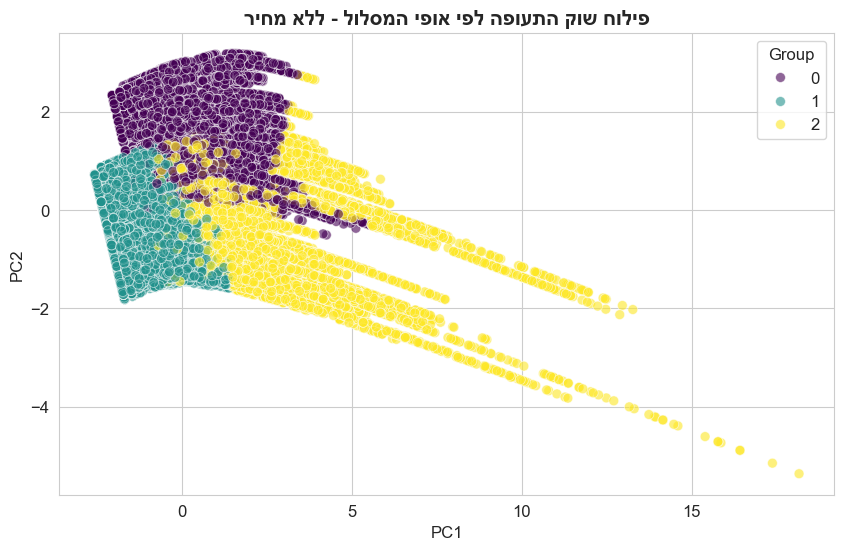

   Cluster  nsmiles  route_density  large_ms    fare  is_leader_cheapest
0        0  1357.89           0.42      0.62  226.54                0.40
1        1  1178.12           0.17      0.69  222.15                0.55
2        2  1082.15           1.00      0.65  209.27                0.40


In [31]:
## AI נכתב בסיוע  

cluster_features = ['nsmiles', 'route_density', 'log_passengers', 'is_hub_origin', 'is_hub_dest']

X_analysis = X_train[cluster_features].copy()


scaler_cluster = StandardScaler()
X_analysis_scaled = scaler_cluster.fit_transform(X_analysis)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_analysis_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_analysis_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.6, s=50)

plt.title('פילוח שוק התעופה לפי אופי המסלול - ללא מחיר'[::-1], fontsize=15, weight='bold')
plt.legend(title='Group')
plt.show()

X_profile = X_train.copy()
X_profile['Cluster'] = clusters
X_profile['is_leader_cheapest'] = y_train

summary_table = X_profile.groupby('Cluster')[
    ['nsmiles', 'route_density', 'large_ms', 'fare', 'is_leader_cheapest']
].mean().reset_index()

print(summary_table.round(2))

<div dir="rtl" style="text-align: right;">

###  ניתוח עסקי: פרופיל הקבוצות (Cluster Profiling)

האלגוריתם (**K-Means**) הצליח לזקק מתוך הנתונים שלושה "אב-טיפוסים" (Archetypes) המאפיינים את שוק התעופה. החלוקה אינה שרירותית, אלא מבוססת על היגיון עסקי מובהק:

1. #### **קבוצה 0: "הטיסות הארוכות" (Long Haul)** 
    * **מאפיין בולט:** מרחק הטיסה הגדול ביותר (`nsmiles` ~ 1,358).
    * **התוצאה:** המחיר היקר ביותר (226$), בשל עלויות תפעול (דלק) גבוהות יותר.
 
3.  #### **קבוצה 1: "הקו הריכוזי" (The Dominant Player)** 
    * **מאפיין בולט:** נתח שוק גבוה (`large_ms` = 69%) וצפיפות נמוכה.
    * **משמעות:** קווים בהם חברה אחת שולטת בשוק (כמעט מונופול).
    * **התוצאה:** לחברה המובילה יש את הסיכוי הגבוה ביותר (**55%**) להיות גם הזולה ביותר, ככל הנראה כי היא מכתיבה את תנאי השוק ואין מתחרים קטנים ששוברים את המחיר.

4.  #### **קבוצה 2: "הזירה התחרותית" (The Competitive Route)** 
     * **מאפיין בולט:** צפיפות מסלול מקסימלית (`route_density` = 1.0).
     * **משמעות:** אלו קווים עמוסים עם ריבוי מתחרים.
     * **התוצאה:** המחיר הממוצע הוא **הנמוך ביותר** (209$), כתוצאה ממלחמות מחירים, והסיכוי של המוביל להיות הכי זול הוא נמוך (39%).


</div>

<div dir="rtl" style="text-align: right;">

###  אימות החלוקה באמצעות DBSCAN

כדי לוודא שהחלוקה לקבוצות אינה שרירותית, נשווה את תוצאות ה-**K-Means** לאלגוריתם **DBSCAN**.

בניגוד ל-K-Means שמחלק את המרחב בצורה גיאומטרית, ה-DBSCAN מחפש אזורים של **צפיפות גבוהה**.
בדיקה זו תאפשר לנו:

1.  לזהות האם ישנם נתונים חריגים (**Noise**) שאינם שייכים לאף קבוצה.
2.  לגלות האם קיימות תתי-קבוצות טבעיות שהמודל הקודם לא זיהה.

</div>

DBSCAN Result: Found 7 clusters.
Noise points detected: 67


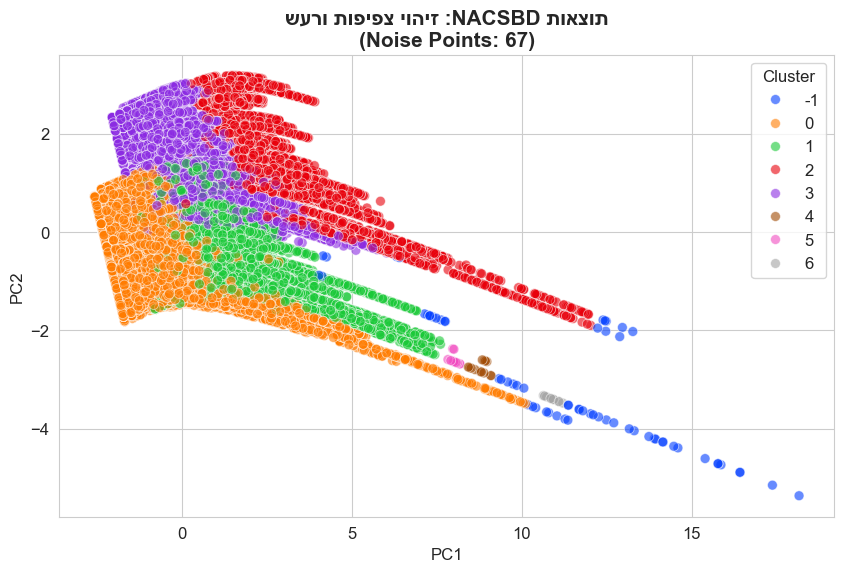

In [34]:
## AI נכתב בסיוע 

dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_clusters = dbscan.fit_predict(X_analysis_scaled) 

n_clusters_ = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)
n_noise_ = list(dbscan_clusters).count(-1)

print(f"DBSCAN Result: Found {n_clusters_} clusters.")
print(f"Noise points detected: {n_noise_}")

df_pca_db = df_pca.copy()
df_pca_db['Cluster_DBSCAN'] = dbscan_clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(x='PC1', y='PC2', hue='Cluster_DBSCAN', data=df_pca_db, 
                palette='bright', alpha=0.6, s=50)

hebrew_title = "תוצאות DBSCAN: זיהוי צפיפות ורעש"[::-1]
english_subtitle = f"\n(Noise Points: {n_noise_})"

plt.title(hebrew_title + english_subtitle, fontsize=15, weight='bold')
plt.legend(title='Cluster', loc='upper right')
plt.show()

In [35]:
## AI נכתב בסיוע  

df_profile = X_train.copy()
df_profile['Cluster_DBSCAN'] = dbscan_clusters

dbscan_summary = df_profile.groupby('Cluster_DBSCAN')[
    ['nsmiles', 'fare', 'large_ms', 'route_density', 'log_passengers']
].agg(
    Count=('nsmiles', 'count'),          # כמה טיסות בקבוצה
    Avg_Distance=('nsmiles', 'mean'),    # מרחק ממוצע
    Avg_Price=('fare', 'mean'),          # מחיר ממוצע
    Market_Share=('large_ms', 'mean'),   # נתח שוק ממוצע
    Competition=('route_density', 'mean') # צפיפות מסלול
).reset_index()

dbscan_summary = dbscan_summary.sort_values(by='Count', ascending=False)

print("\n--- משמעות עסקית ל-7 הקבוצות (DBSCAN Profiles) ---")
print(dbscan_summary.round(2))


--- משמעות עסקית ל-7 הקבוצות (DBSCAN Profiles) ---
   Cluster_DBSCAN   Count  Avg_Distance  Avg_Price  Market_Share  Competition
1               0  116424       1155.33     218.89          0.69         0.26
2               1   44725       1162.39     219.94          0.65         0.61
4               3   32013       1291.27     221.55          0.63         0.35
3               2   10057       1379.47     225.18          0.58         1.54
0              -1      67        364.93     135.70          0.50        14.41
5               4      13        259.15     143.93          0.56        11.12
6               5      11        238.64     156.64          0.52         9.98
7               6      10        209.00     131.72          0.53        14.37


<div dir="rtl" style="text-align: right;">

###  ניתוח ממצאי DBSCAN: השוק המרכזי מול קצוות

<p>הטבלה חושפת תובנה מרתקת על מבנה הנתונים:</p>

1.  **השוק המרכזי (Core Market):**
    רוב הטיסות (Clusters 0, 1, 2, 3) מתנהגות בצורה דומה – טווחים בינוניים-ארוכים ומחירים יציבים. ההבדל העיקרי ביניהן הוא רמת התחרותיות בקו, אך מבחינה אסטרטגית הן מייצגות את ה"מיינסטרים" של התעופה.

2.  **זיהוי חריגים (Anomaly Detection):**
    האלגוריתם הצליח לבודד בדיוק רב קבוצות זעירות (Clusters 4, 5, 6) המאופיינות בטיסות קצרות מאוד (<400 מייל) וברמת תחרותיות (Density) קיצונית של פי 50 מהממוצע. אלו ככל הנראה קווי "שאטל" עמוסים במיוחד (כגון ניו-יורק–וושינגטון).

**מסקנת ביניים:**
בעוד ש-DBSCAN מצטיין בזיהוי מקרי קצה וחריגים, הוא יצר חלוקה לא מאוזנת (4 קבוצות ענק ו-4 קבוצות זניחות). תובנה זו מחזקת את הצורך במודל מכליל יותר כמו K-Means לבניית אסטרטגיה רוחבית.

</div>

<div dir="rtl" style="text-align: right;">

<h3 style="color: #2c3e50;"> הכרעה: מדוע K-Means עדיף על DBSCAN? (ניתוח חפיפה)</h3>

<p>בהשוואה למודל ה-DBSCAN (שמצא 4 קבוצות עיקריות ועוד 3 קבוצות קצה), אנו רואים יתרון מובהק ל-K-Means בראייה עסקית:</p>

<ul>
    <li>
        <b> הבעיה ב-DBSCAN (יתירות):</b><br>
        בטבלת ה-DBSCAN ניתן לראות כי קבוצות 0, 1 ו-3 היו כמעט זהות במחיר (סביב 220$) ובמרחק. האלגוריתם פיצל אותן לקבוצות נפרדות רק בגלל הבדלי צפיפות טכניים, ללא הצדקה עסקית.
    </li>
    <br>
    <li>
        <b> הפתרון של K-Means (הכללה חכמה):</b><br>
        מודל ה-K-Means "הבין" שאין טעם לפצל קבוצות בעלות מאפיינים דומים, ואיחד אותן על בסיס התנהגות עסקית משותפת (למשל: איחוד כל הטיסות הארוכות לקטגוריית "Long Haul").
    </li>
</ul>

<hr>

<h4> מסקנה סופית:</h4>
<p>
    בעוד ש-DBSCAN יצר <b>"רעש ניהולי"</b> (יותר מדי קבוצות עם מאפיינים דומים), K-Means יצר <b>"סדר ניהולי"</b> (3 קטגוריות מובחנות וברורות: תחרותי, ריכוזי, וארוך-טווח).
</p>

<div style="background-color: #f0f9ff; padding: 10px; border-right: 5px solid #007bff; border-radius: 4px;">
    <b>לכן, K-Means הוא המודל הנבחר לניתוח השוק בפרויקט זה.</b>
</div>

</div>